# Monte Carlo: устойчивость калибровок PD к составу портфеля

Проверяем, насколько результаты сравнения калибраторов зависят от конкретного сгенерированного портфеля. Логика:

- **RF и все калибраторы обучаются один раз** на полном in-time периоде 2020-2023 — внутри сценариев ничего не переобучается;
- каждый сценарий независимо берет **~80% наблюдений без возврата** отдельно из in-time и отдельно из OOT 2024;
- подвыборки прогоняются через уже готовый пайплайн `score -> calibrated PD -> EL / UL / Capital / RWA`;
- по каждому сценарию и методу считаются:
  - p-value биномиального теста на IN-TIME и на OOT (min binomial p-value по 10 квантильным бинам — та же конструкция, что в разделе 7.1 основного ноутбука);
  - средний PD на OOT;
  - Expected Loss, Unexpected Loss capital, RWA и Required Capital (те же допущения, что в разделе 8.1: EAD = 1 млн на актив, LGD = 40%, M = 2.5).

Итоговая таблица показывает для каждого метода **среднее, минимум, максимум и разницу max-min** — чем уже разброс, тем меньше результат зависит от случайного состава портфеля.

Вычислительный движок лежит в `notebooks/monte_carlo.py`; этот ноутбук — его отчетная обертка с таблицами и графиками.

In [1]:
import sys

for extra_path in ("..", "."):
    if extra_path not in sys.path:
        sys.path.append(extra_path)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from matplotlib.ticker import PercentFormatter

from monte_carlo import (
    METRIC_COLUMNS,
    prepare_fixed_pipeline,
    run_scenario,
    summarize_monte_carlo,
)

plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 11
COLORS = ["#e74c3c", "#2980b9", "#27ae60", "#e67e22", "#8e44ad", "#16a085"]

N_SCENARIOS = 10  # старт с малого числа; масштабирование до 1000 — после проверки
SAMPLE_FRAC = 0.8

print(f"Сценариев: {N_SCENARIOS} | доля подвыборки: {SAMPLE_FRAC:.0%}")

Сценариев: 10 | доля подвыборки: 80%


## 1. Фиксированный пайплайн

Один раз генерируем тот же синтетический stress-портфель (random_state=42, как в основном ноутбуке), обучаем RF и все пять калибраторов на полном in-time. Дальше эти объекты не меняются.

In [2]:
pipeline = prepare_fixed_pipeline(portfolio="stress", random_state=42)

n_intime = len(pipeline["x_calib"])
n_oot = len(pipeline["x_test"])
ct_intime = float(pipeline["y_calib"].mean())
dr_oot = float(pipeline["y_test"].mean())

print(f"In-time (2020-2023): {n_intime:,} строк | ЦТ = {ct_intime:.2%}")
print(f"OOT (2024):          {n_oot:,} строк | фактическая доля дефолтов = {dr_oot:.2%}")
print(f"Размер сценарной подвыборки: ~{int(n_intime * SAMPLE_FRAC):,} in-time / ~{int(n_oot * SAMPLE_FRAC):,} OOT строк")
print(f"Методы: {', '.join(pipeline['calibrators'])}")

In-time (2020-2023): 31,224 строк | ЦТ = 4.81%
OOT (2024):          8,776 строк | фактическая доля дефолтов = 4.73%
Размер сценарной подвыборки: ~24,979 in-time / ~7,020 OOT строк
Методы: Логит-калибровка, Изотоническая регрессия, Бета-калибровка, Монотонный сплайн, Французский сплайн


## 2. Прогон сценариев

Каждый сценарий использует свой seed (0..N-1), поэтому весь эксперимент воспроизводим.

In [3]:
scenario_results = pd.concat(
    [run_scenario(pipeline, scenario_seed=seed, sample_frac=SAMPLE_FRAC) for seed in range(N_SCENARIOS)],
    ignore_index=True,
)

money_cols = ["expected_loss", "unexpected_loss_capital", "rwa", "required_capital"]
scenario_view = scenario_results.copy()
for col in money_cols:
    scenario_view[col + "_bln"] = scenario_view[col] / 1e9
scenario_view = scenario_view.drop(columns=money_cols)

print(f"Всего строк: {len(scenario_results)} ({N_SCENARIOS} сценариев x {scenario_results['method'].nunique()} методов)")
display(
    scenario_view.style.format({
        "p_value_intime": "{:.6f}",
        "p_value_oot": "{:.6f}",
        "oot_mean_pd": "{:.4%}",
        "expected_loss_bln": "{:.4f}",
        "unexpected_loss_capital_bln": "{:.4f}",
        "rwa_bln": "{:.4f}",
        "required_capital_bln": "{:.4f}",
    })
)

Всего строк: 50 (10 сценариев x 5 методов)


,scenario,method,p_value_intime,p_value_oot,oot_mean_pd,expected_loss_bln,unexpected_loss_capital_bln,rwa_bln,required_capital_bln
0,0,Логит-калибровка,0.002559,0.062177,4.8552%,0.1364,0.5413,6.7658,0.5413
1,0,Изотоническая регрессия,0.328227,0.000009,4.8438%,0.1361,0.5213,6.5161,0.5213
2,0,Бета-калибровка,0.000559,0.096213,4.8478%,0.1361,0.5474,6.8426,0.5474
3,0,Монотонный сплайн,0.376125,0.000044,4.8596%,0.1365,0.5249,6.5619,0.5249
4,0,Французский сплайн,0.271744,0.002357,4.8562%,0.1364,0.5249,6.5606,0.5249
5,1,Логит-калибровка,0.002224,0.009747,4.9548%,0.1392,0.5457,6.8212,0.5457
6,1,Изотоническая регрессия,0.063475,0.000001,4.9645%,0.1394,0.5263,6.5782,0.5263
7,1,Бета-калибровка,0.000409,0.018145,4.9469%,0.1389,0.5516,6.8953,0.5516
8,1,Монотонный сплайн,0.053587,0.000001,4.9699%,0.1396,0.5300,6.6245,0.5300
9,1,Французский сплайн,0.115842,0.000077,4.9653%,0.1395,0.5298,6.6231,0.5298


## 3. Итоговая таблица: среднее / минимум / максимум / разброс

Ключевой показатель — **range (max - min)**: он показывает, насколько сильно метрика гуляет между сценариями при неизменной модели и калибровке.

In [4]:
summary = summarize_monte_carlo(scenario_results)

metric_titles = {
    "p_value_intime": ("Min binomial p-value, IN-TIME", "{:.6f}"),
    "p_value_oot": ("Min binomial p-value, OOT", "{:.6f}"),
    "oot_mean_pd": ("Средний PD на OOT", "{:.4%}"),
    "expected_loss": ("Expected Loss, млрд", None),
    "unexpected_loss_capital": ("UL capital, млрд", None),
    "rwa": ("RWA, млрд", None),
    "required_capital": ("Required capital, млрд", None),
}

for metric in METRIC_COLUMNS:
    title, fmt = metric_titles[metric]
    block = summary[["method"] + [f"{metric}_{s}" for s in ("mean", "min", "max", "range")]].copy()
    block.columns = ["method", "mean", "min", "max", "range (max-min)"]
    if fmt is None:
        for col in ("mean", "min", "max", "range (max-min)"):
            block[col] = block[col] / 1e9
        fmt = "{:.4f}"
    print(title)
    display(block.style.format({c: fmt for c in ("mean", "min", "max", "range (max-min)")}).hide(axis="index"))

Min binomial p-value, IN-TIME


method,mean,min,max,range (max-min)
Бета-калибровка,0.002958,0.000108,0.011375,0.011267
Изотоническая регрессия,0.481861,0.063475,0.678144,0.614669
Логит-калибровка,0.008361,0.000604,0.030041,0.029438
Монотонный сплайн,0.364181,0.053587,0.680898,0.627311
Французский сплайн,0.187895,0.115842,0.337180,0.221339


Min binomial p-value, OOT


method,mean,min,max,range (max-min)
Бета-калибровка,0.040469,0.005044,0.096213,0.091168
Изотоническая регрессия,0.000047,0.000000,0.000390,0.000390
Логит-калибровка,0.030137,0.002371,0.072952,0.070581
Монотонный сплайн,0.000205,0.000000,0.001683,0.001683
Французский сплайн,0.002219,0.000008,0.017087,0.017079


Средний PD на OOT


...

method,mean,min,max,range (max-min)
Бета-калибровка,0.5492,0.5472,0.5521,0.0048
Изотоническая регрессия,0.5235,0.5213,0.5266,0.0053
Логит-калибровка,0.5432,0.5412,0.5462,0.0051
Монотонный сплайн,0.5272,0.5249,0.5304,0.0055
Французский сплайн,0.5271,0.5249,0.5302,0.0054


RWA, млрд


method,mean,min,max,range (max-min)
Бета-калибровка,6.8646,6.8404,6.9009,0.0605
Изотоническая регрессия,6.5436,6.5161,6.5829,0.0668
Логит-калибровка,6.7894,6.7647,6.8280,0.0633
Монотонный сплайн,6.5897,6.5619,6.6302,0.0683
Французский сплайн,6.5882,6.5606,6.6280,0.0673


Required capital, млрд


method,mean,min,max,range (max-min)
Бета-калибровка,0.5492,0.5472,0.5521,0.0048
Изотоническая регрессия,0.5235,0.5213,0.5266,0.0053
Логит-калибровка,0.5432,0.5412,0.5462,0.0051
Монотонный сплайн,0.5272,0.5249,0.5304,0.0055
Французский сплайн,0.5271,0.5249,0.5302,0.0054


## 4. Визуализация разброса

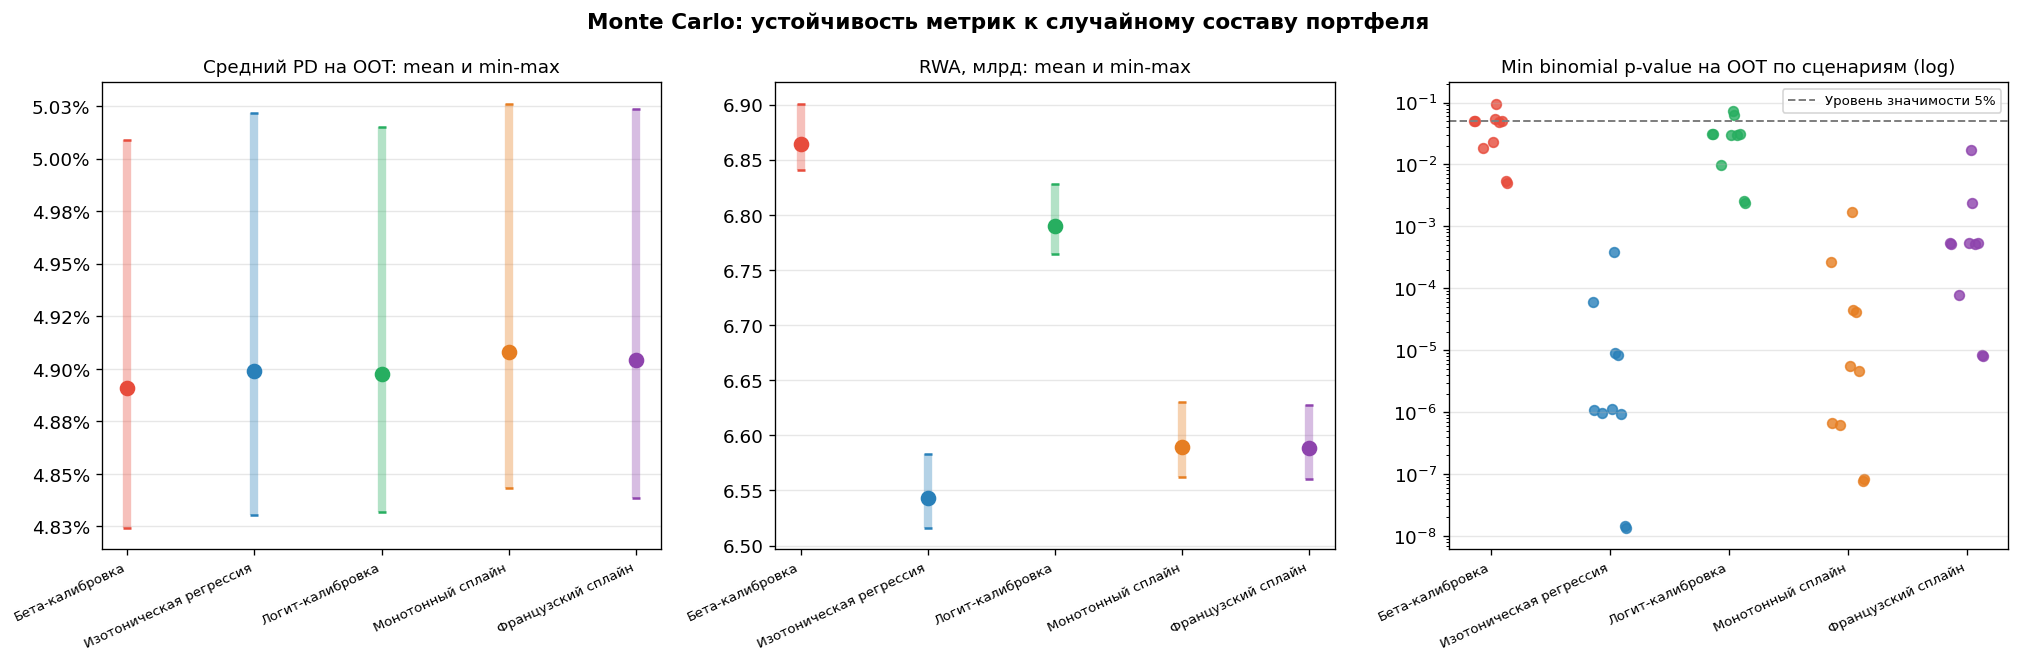

In [5]:
methods = list(summary["method"])
method_colors = {name: COLORS[i % len(COLORS)] for i, name in enumerate(methods)}

fig, axes = plt.subplots(1, 3, figsize=(17, 5.6))

def range_panel(ax, metric, title, scale=1.0, formatter=None):
    for i, name in enumerate(methods):
        row = summary.loc[summary["method"] == name].iloc[0]
        mean = row[f"{metric}_mean"] / scale
        lo = row[f"{metric}_min"] / scale
        hi = row[f"{metric}_max"] / scale
        color = method_colors[name]
        ax.vlines(i, lo, hi, color=color, lw=5, alpha=0.35)
        ax.scatter([i], [mean], color=color, s=70, zorder=5)
        ax.scatter([i, i], [lo, hi], color=color, s=28, marker="_", zorder=5)
    ax.set_xticks(range(len(methods)))
    ax.set_xticklabels(methods, rotation=25, ha="right", fontsize=8)
    ax.set_title(title, fontsize=11)
    if formatter is not None:
        ax.yaxis.set_major_formatter(formatter)
    ax.grid(axis="y", alpha=0.3)

range_panel(axes[0], "oot_mean_pd", "Средний PD на OOT: mean и min-max", formatter=PercentFormatter(1.0, decimals=2))
range_panel(axes[1], "rwa", "RWA, млрд: mean и min-max", scale=1e9)

ax = axes[2]
for i, name in enumerate(methods):
    vals = scenario_results.loc[scenario_results["method"] == name, "p_value_oot"]
    jitter = np.random.default_rng(0).uniform(-0.15, 0.15, len(vals))
    ax.scatter(np.full(len(vals), i) + jitter, vals, color=method_colors[name], s=34, alpha=0.8)
ax.axhline(0.05, color="gray", linestyle="--", lw=1.2, label="Уровень значимости 5%")
ax.set_yscale("log")
ax.set_xticks(range(len(methods)))
ax.set_xticklabels(methods, rotation=25, ha="right", fontsize=8)
ax.set_title("Min binomial p-value на OOT по сценариям (log)", fontsize=11)
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.3)

plt.suptitle("Monte Carlo: устойчивость метрик к случайному составу портфеля", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 5. Интерпретация

- **Средний PD на OOT и денежные метрики (EL / UL / RWA / Capital) устойчивы**: разброс max-min составляет доли процента от уровня метрики. Выводы раздела 8 основного ноутбука не зависят от того, какие именно ~80% портфеля попали в выборку.
- **Биномиальный тест на OOT ведет себя по-разному у разных методов.** Широкий разброс p-value сам по себе ожидаем: min binomial p-value чувствителен к случайному числу дефолтов в отдельном квантильном бине. Структурный сигнал — это когда p-value значим на **всех** сценариях (максимум по сценариям около нуля), а не только в среднем: такой метод стабильно ловится тестом на разладку, и это свойство метода, а не эффект неудачной подвыборки.
- На IN-TIME картина обратная у методов с точной подгонкой уровня: у них p-value заметно выше, потому что fit-выборка — это та же популяция, на которой откалиброван уровень PD.

**Следующий шаг** — масштабирование до 1000 сценариев (после проверки текущих результатов). Перед этим стоит перенести RF-скоринг из сценария в подготовку пайплайна (предсказать один раз на полных выборках и в сценариях только индексировать) — это сократит время 1000 ранов с десятков минут до минут.